<a href="https://colab.research.google.com/github/Bloop15/DL-2026-2027/blob/main/Sequence_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

In [8]:
def generate_sequence(seq_length=5,num_samples=1000):
  X, y=[], []

  for _ in range (num_samples):
    seq= np.random.rand(seq_length)
    X.append(seq)
    y.append(seq[-1]+0.1)

  return np.array(X), np.array(y)

In [11]:
seq_length= 5
X, y= generate_sequence(seq_length)

X = X.reshape((X.shape[0], seq_length, 1))

split= int(0.8*len(X))
X_train, y_train= X[:split], y[:split]
X_test, y_test= X[split:], y[split:]

In [12]:
model= Sequential([

    SimpleRNN(10, activation='relu', input_shape=(seq_length,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
history= model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0624 - val_loss: 0.0219
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0134 - val_loss: 0.0115
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0066 - val_loss: 0.0056
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - val_loss: 0.0024
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.5704e-04 - val_loss: 7.9203e-04
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.0223e-04 - val_loss: 5.5734e-04
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.4155e-04 - val_loss: 4.2993e-04
Epoch 9/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.4544e-04 - val_loss: 3.3782e-04
Epoch 10/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8642e-04 - val_loss: 2.8809e-04
Epoch 11/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.4375e-04 - val_loss: 2.5452e-04
Epoch 12/50
50/50 ━━━━━━━━

In [16]:
test_loss= model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5267e-05 
Test Loss: 1.5266938135027885e-05


In [17]:
sample_input= np.array([0.1, 0.2, 0.3, 0.4, 0.5]).reshape(1, seq_length, 1)
predicted_value= model.predict(sample_input)
print(f"Predicted next value: {predicted_value}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Predicted next value: [[0.60068417]]


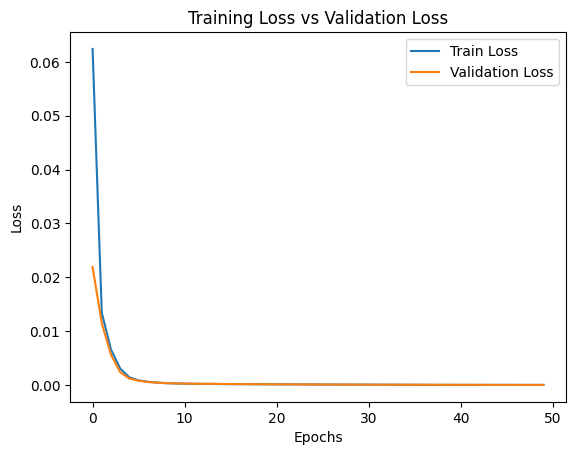

In [18]:
plt.plot(history.history["loss"], label='Train Loss')
plt.plot(history.history["val_loss"], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Loss vs Validation Loss")
plt.show()